# Experiment 3C: Random-Label Memorization with Adam

### Objective
To investigate whether changing the optimizer enables the overparameterized network to memorize randomly assigned labels.

This experiment uses the same random-label setting as Experiments 3A and 3B, but replaces SGD with Adam.

### Experimental Configuration

- Dataset: MNIST
- Width: 2048
- Parameters: 10,020,874
- Optimizer: Adam
- Learning rate: 0.001
- Batch size: 128
- Epochs: 100
- Labels: Randomly assigned

Device: cuda
Width: 2048
Epochs: 100
Batch size: 128
Learning rate: 0.001


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 347kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.25MB/s]



Training samples: 60000
Test samples: 10000

Total parameters: 10020874
Epoch 001/100 | Train Loss: 2.3034 | Train Acc: 9.84% | Test Loss: 2.3045 | Test Acc: 7.66%
Epoch 002/100 | Train Loss: 2.3031 | Train Acc: 9.86% | Test Loss: 2.3026 | Test Acc: 10.99%
Epoch 003/100 | Train Loss: 2.3030 | Train Acc: 10.15% | Test Loss: 2.2981 | Test Acc: 10.32%
Epoch 004/100 | Train Loss: 2.3031 | Train Acc: 10.20% | Test Loss: 2.3053 | Test Acc: 8.72%
Epoch 005/100 | Train Loss: 2.3030 | Train Acc: 10.08% | Test Loss: 2.3052 | Test Acc: 12.75%
Epoch 006/100 | Train Loss: 2.3031 | Train Acc: 10.03% | Test Loss: 2.3015 | Test Acc: 3.82%
Epoch 007/100 | Train Loss: 2.3028 | Train Acc: 10.28% | Test Loss: 2.2929 | Test Acc: 10.87%
Epoch 008/100 | Train Loss: 2.3025 | Train Acc: 10.53% | Test Loss: 2.3032 | Test Acc: 9.12%
Epoch 009/100 | Train Loss: 2.3018 | Train Acc: 10.40% | Test Loss: 2.3020 | Test Acc: 10.79%
Epoch 010/100 | Train Loss: 2.3005 | Train Acc: 10.68% | Test Loss: 2.3079 | Test Acc: 

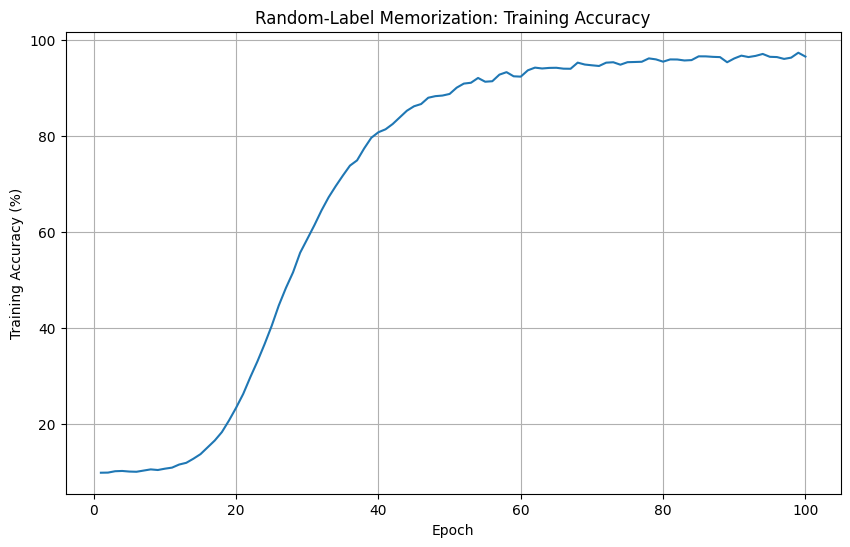

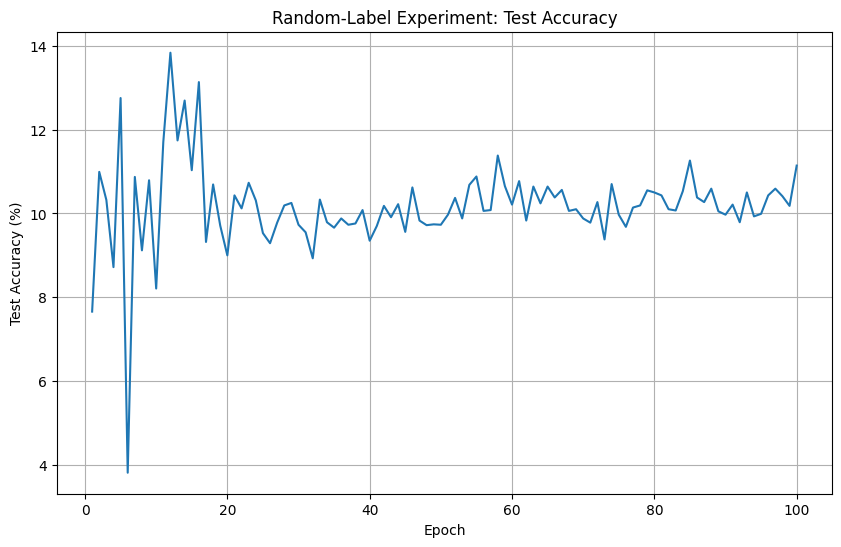

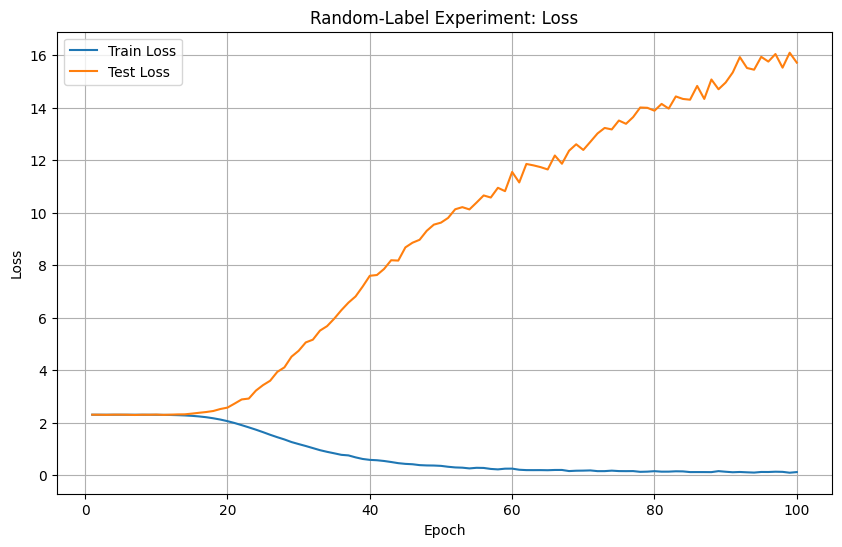

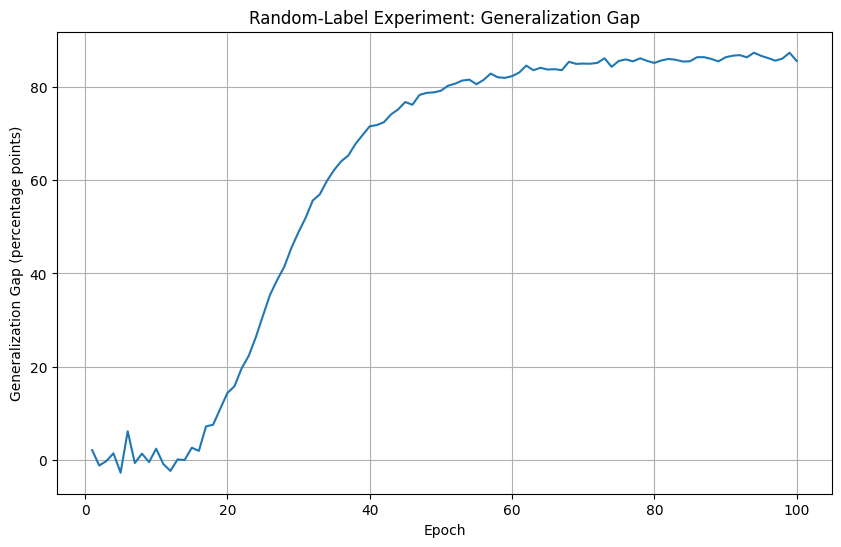


Saved: experiment_3_random_labels_adam.csv


In [ ]:
# ============================================================
# EXPERIMENT 3C: MEMORIZATION OF RANDOM LABELS
# 2048-WIDTH MLP + ADAM
# ============================================================

# ============================================================
# 1. IMPORTS
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import random
import time


# ============================================================
# 2. SETTINGS
# ============================================================

SEED = 42

WIDTH = 2048
EPOCHS = 100
BATCH_SIZE = 128
LEARNING_RATE = 0.001


# ============================================================
# 3. REPRODUCIBILITY
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 4. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("Width:", WIDTH)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)


# ============================================================
# 5. LOAD MNIST
# ============================================================

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("\nTraining samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


# ============================================================
# 6. CREATE RANDOM LABEL DATASET
# ============================================================

class RandomLabelDataset(Dataset):

    def __init__(self, dataset, seed=42):

        self.dataset = dataset

        generator = torch.Generator()
        generator.manual_seed(seed)

        self.random_labels = torch.randint(
            0,
            10,
            (len(dataset),),
            generator=generator
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):

        image, _ = self.dataset[index]

        # Original label is ignored.
        # Random label is returned instead.
        return image, self.random_labels[index]


random_train_dataset = RandomLabelDataset(
    train_dataset,
    seed=SEED
)


# ============================================================
# 7. DATA LOADERS
# ============================================================

random_train_loader = DataLoader(
    random_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# IMPORTANT:
# Test set still has ORIGINAL MNIST labels.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 8. MODEL
# ============================================================

class MLP(nn.Module):

    def __init__(self, width):

        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, 10)
        )

    def forward(self, x):

        return self.network(x)


# ============================================================
# 9. CREATE MODEL
# ============================================================

torch.manual_seed(SEED)

model = MLP(WIDTH).to(device)


# ============================================================
# 10. COUNT PARAMETERS
# ============================================================

parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTotal parameters:", parameters)


# ============================================================
# 11. LOSS FUNCTION + ADAM
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# 12. TRAINING
# ============================================================

history = []

start_time = time.time()

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in random_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total

    train_accuracy = (
        100 * correct / total
    )


    # --------------------------------------------------------
    # TEST
    # --------------------------------------------------------

    model.eval()

    test_running_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            test_running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            test_correct += (
                predictions == labels
            ).sum().item()

            test_total += labels.size(0)

    test_loss = test_running_loss / test_total

    test_accuracy = (
        100 * test_correct / test_total
    )


    # --------------------------------------------------------
    # GENERALIZATION GAP
    # --------------------------------------------------------

    generalization_gap = (
        train_accuracy - test_accuracy
    )


    # --------------------------------------------------------
    # SAVE RESULTS
    # --------------------------------------------------------

    history.append({

        "epoch": epoch + 1,

        "train_loss": train_loss,

        "train_accuracy": train_accuracy,

        "test_loss": test_loss,

        "test_accuracy": test_accuracy,

        "generalization_gap": generalization_gap
    })


    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    print(
        f"Epoch {epoch+1:03d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy:.2f}%"
    )


# ============================================================
# 13. RESULTS DATAFRAME
# ============================================================

results = pd.DataFrame(history)


# ============================================================
# 14. TRAINING TIME
# ============================================================

training_time = time.time() - start_time

print(
    f"\nTraining time: "
    f"{training_time / 60:.2f} minutes"
)


# ============================================================
# 15. FINAL RESULT
# ============================================================

print("\n" + "=" * 70)
print("FINAL RESULT")
print("=" * 70)

print(
    results.iloc[-1].to_string()
)


# ============================================================
# 16. TRAINING ACCURACY PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    results["epoch"],
    results["train_accuracy"]
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")

plt.title(
    "Random-Label Memorization: Training Accuracy"
)

plt.grid(True)

plt.show()


# ============================================================
# 17. TEST ACCURACY PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    results["epoch"],
    results["test_accuracy"]
)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")

plt.title(
    "Random-Label Experiment: Test Accuracy"
)

plt.grid(True)

plt.show()


# ============================================================
# 18. LOSS PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    results["epoch"],
    results["train_loss"],
    label="Train Loss"
)

plt.plot(
    results["epoch"],
    results["test_loss"],
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Random-Label Experiment: Loss"
)

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 19. GENERALIZATION GAP
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    results["epoch"],
    results["generalization_gap"]
)

plt.xlabel("Epoch")
plt.ylabel(
    "Generalization Gap (percentage points)"
)

plt.title(
    "Random-Label Experiment: Generalization Gap"
)

plt.grid(True)

plt.show()


# ============================================================
# 20. SAVE RESULTS
# ============================================================

results.to_csv(
    "experiment_3_random_labels_adam.csv",
    index=False
)

print(
    "\nSaved: "
    "experiment_3_random_labels_adam.csv"
)

Now the model successfully memorized the random labels.

### Conclusion

After 100 epochs, the model achieved 96.62% training accuracy on the random labels, while test accuracy remained at 11.14%, close to the 10% chance level.

Thus, under the Adam configuration, the network was able to memorize the random labels without generalizing to the original test labels.